### Demoblatt
--- 



# `Neural Network Classifier`



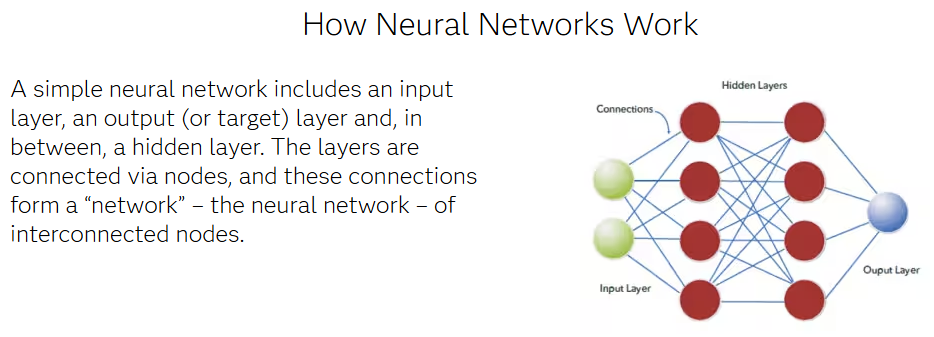  
https://www.sas.com/el_gr/insights/analytics/neural-networks.html

Ein Neurales Netz besteht aus mehreren Schichten (`Layers`), wobei jede Schicht eine bestimmte Anzahl von Knoten (`Nodes`) besteht.<br>
Diese Layer werden auch hidden_Layers genannt. 

```` python
 mlp_clf = MLPClassifier(hidden_layer_sizes=(5,2),    # Layer 1: 5 Nodes; Layer 2: 2 Nodes
                         max_iter = 300, 
                         activation = 'relu',          
                         solver = 'adam')
````
würde folgendes Netz erzeugen:

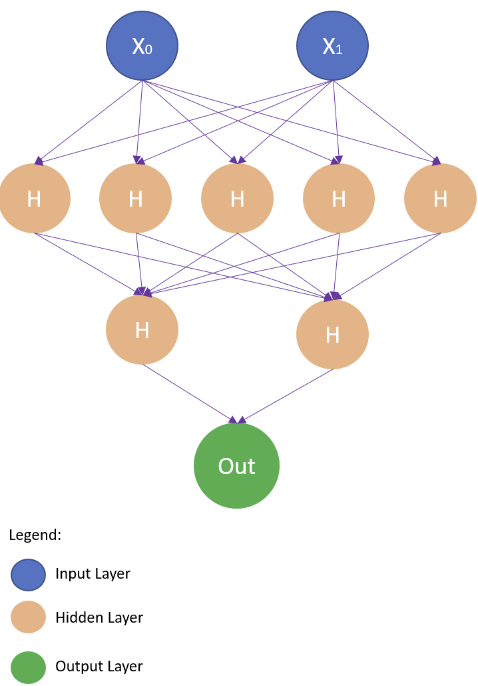

<div style="background-color:rgba(250, 250, 0, 0.1)">

---

# Aufgabe: 

Vorhersage der Weinqualität auf Grund von ``proline`` und ``hue``.

---



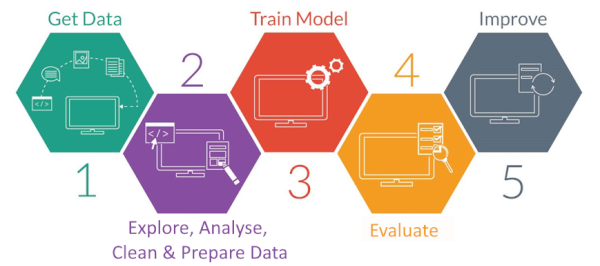

---
# ``Schritt 1:`` Daten laden

Zuerst werden die Daten in den Hauptspeicher geladen. Im Beispiel wird die Funktion `sklearn.datasets.load_wine` verwendet.

In [ ]:
from sklearn import datasets
import pandas as pd

#-------------------------------------------------------------------------
# Laden der Daten
dfWine, target = datasets.load_wine( return_X_y=True, as_frame=True )

dfWine['class'] = target.replace({0:'class_0',1:'class_1', 2:'class_2'})

dfWine.head()

---
# ``Schritt 2:`` Data Preprocessing


### Daten auswählen

Erstellen eines Dataframes mit den Fetures, welche für die Vorhersage verwendet werden sollen und eines für das Feature, welches vorhergesagt werden soll.


In [ ]:
#------------------------------------------------------------
# Features auswählen
cols_x  = ['proline', 'hue']  # independent
cols_y  = 'class'             # dependent: Vorhersagen

#------------------------------------------------------------
dfLearn_X = dfWine[cols_x]
dfLearn_Y = dfWine[cols_y]

### Features Skalieren

In [ ]:
#-------------------------------------------------------------
# Führe später die Übung ein weiteres mal mit skalierten Daten durch
# ---> Dein Code 



### Trainings- und Testdaten erstellen

In [ ]:
from sklearn.model_selection import train_test_split

#------------------------------------------------------------
testsize = 0.3
dfTrain_x, dfTest_x, dfTrain_y, dfTest_y = train_test_split( dfLearn_X, dfLearn_Y,
                test_size= testsize, 
                random_state=0)

#------------------------------------------------------------
# Dataframe in Array umrechnens
train_x = dfTrain_x.values       # independent
train_y = dfTrain_y.values       # dependent

test_x  = dfTest_x.values        # independent
test_y  = dfTest_y.values        # dependent
#------------------------------------------------------------

---
# ``Schritt 3:`` Modell erstellen und trainieren


### Modell erstellen und trainieren



In [ ]:
from sklearn.neural_network import MLPClassifier

#------------------------------------------------------------
# Modell erstellen und trainieren
model = MLPClassifier( alpha=0.7, max_iter=1000,
                       learning_rate='adaptive',
                      # hidden_layer_sizes=(100)
                      #  activation = 'relu',
                      #  solver = 'adam'
                      )
model.fit(train_x, train_y) 

### Vorhersagen erstellen
Erstelle mit dem trainierten Modell nun für die Trainings- und Testdaten die jeweiligen Vorhersagen.


In [ ]:
#------------------------------------------------------------
# Vorhersagen für die Trainingsdaten erstellen
pred_train_y = model.predict(train_x)

#------------------------------------------------------------
# Vorhersagen für die Testdaten erstellen
pred_y = model.predict(test_x)

Visueller Vergleich der tatsächlichen und der vorhergesagten Werte

In [ ]:
# Vergleiche die ersten 5 Werte der Testdaten mit den vorhergesagten Werten
print("Testdaten: ")
print ("Tatsächlich: ", test_y [0:5])
print ("Vorhersagen: ", pred_y [0:5])

---
# ``Schritt 4:`` Evaluieren


## Genauigkeit des Modells

Die Genauigkeit der Vorhersage kann mittels eines **``accuracy_score``** ermittelt werden.

In [ ]:
# Prüfen der Genauigkeit des Models
from sklearn import metrics

print("Genauigkeit der Trainingsdaten:  %.3f " %  metrics.accuracy_score(train_y, pred_train_y))
print("Genauigkeit der Testdaten:       %.3f " %  metrics.accuracy_score(test_y, pred_y))

<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Was kannst du über die Genauigkeit des Modells sagen?**<br>
Begründe deine Antwort!<br>  
 


---
</div>

## Visualisieren der Entscheidungsgrenzen


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
%matplotlib inline

#------------------------------------------------------------
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

#------------------------------------------------------------
# Entscheidungsgrenzen des Modells visualisieren
axs[0].set_title('Trainings-Accuracy', loc='left',color='r', fontsize=12)
DecisionBoundaryDisplay.from_estimator( 
            model, train_x, xlabel='proline',ylabel='hue', 
            alpha=0.5, eps=0.5, ax=axs[0], cmap = 'brg')

axs[1].set_title('Test-Accuracy', loc='left',color='r', fontsize=12)
DecisionBoundaryDisplay.from_estimator(
            model, test_x, xlabel='proline',ylabel='hue', 
            alpha=0.5, eps=0.5, ax=axs[1], cmap = 'brg')

#------------------------------------------------------------
# Tatsächliche Werte anzeigen
sns.scatterplot(x=train_x[:,0], y=train_x[:,1], hue=train_y, palette= ['b','r','g'],  ax=axs[0], hue_order=model.classes_)
sns.scatterplot(x=test_x [:,0], y=test_x [:,1], hue=test_y,  palette= ['b','r','g'],  ax=axs[1], hue_order=model.classes_)

plt.show()

---

## Praxistest



In [ ]:
# Testdaten generieren
proline = 800
hue  = 0.75
test_data = [[proline, hue]]

# Vorhersage erstellen
wclass = model.predict(test_data)

# Species ausgeben
print("Vorhersage der Klasse: ", wclass[0])

Nun stellt sich noch die Frage, wie hoch ist die Wahrscheinlichkeit das die Vorhersage richtig ist.  
Dazu kann mit ``predict_proba``, die Wahrscheinlichkeit für jede einzelne Kategorie ermittelt werden.

In [ ]:
prob = model.predict_proba( test_data )

print("Wahrscheinlichkeit: ", prob)

for art in range(0,3):
    proz = prob[0,art]*100
    name = model.classes_[art]
    print('%-12s' % name, '%5.1f %%' % proz )

<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Vergleiche das Ergebnis mit dem zugehörigen Wert aus den Beobachtungen.**<br>
*Erläutere weiters wie wahrscheinlich das Ergebnis ist.*<br>  



---
</div>

---
# ``Schritt 5:`` Improve



### ELLBOW-Methode: ``Finden der besten Genauigkeit``


Bei Neuralen Netzen gibt es viele Möglichkeiten das Modell zu optimieren. Als einfaches Beispiel verändern wir hier ``alpha.``

In [ ]:
import numpy as np

training_accuracy = []
test_accuracy = []

# Bereich festlegen
test_range = np.linspace(0.1, 1, 20)

for c in test_range :    
    # Model trainieren 
    model = MLPClassifier(alpha=c, learning_rate='adaptive', max_iter=1000)
    model.fit(train_x,train_y)

    # Trainingsgenauigkeit bestimmen
    pred  = model.predict(train_x)
    score = metrics.accuracy_score(train_y, pred)
    training_accuracy.append(score)

    # Testgenauigkeit bestimmen
    pred  = model.predict(test_x)
    score = metrics.accuracy_score(test_y, pred)
    test_accuracy.append(score)

best_alpha = test_range[ np.argmax(test_accuracy) ]
best_score = max(test_accuracy)

# Ausgabe aller Scores 
print( "Höchste TEST-Genauigkeit ist %.3f" % best_score, "mit alpha=", best_alpha) 


#### Verlauf der Genauigkeit


In [ ]:
plt.plot(test_range, training_accuracy, label="Trainings-Genauigkeit")
plt.plot(test_range, test_accuracy,     label="Test-Genauigkeit")
plt.ylabel("Accuracy")
plt.xlabel("Alpha")
plt.legend()
#plt.savefig('knn_compare_model')

plt.show()